In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df= pd.read_csv("/content/House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print(df.describe(include="all"))

# Drop ID column
df = df.drop(columns=["Id"], errors="ignore")

#check target distribution
print(df["Price"].describe())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
Duplicate rows: 0
                 Id         Area     Bedrooms   Bathrooms       Floors  \
count   2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
unique          NaN          NaN          NaN         NaN          NaN   
top             NaN          NaN          NaN         NaN          NaN   
freq            NaN          NaN          NaN         NaN          NaN   
mean    1000.500000  2786.209500     3.003500     2.55250     1.993500   
std      577.494589  1295.146799     1.424606     1.10899     0.809188   
min        1.000000   501.000000     1.000000     1.00000     1.000000   
25%      500.750000  1653.000000     2.000000     2.00000     1.000000   
50%     1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%     1500.250000  3887.500000     4.000000     4.00000     3.000000   
max  

Define price and target

In [ ]:
X = df.drop(columns=["Price"])
y = df["Price"]

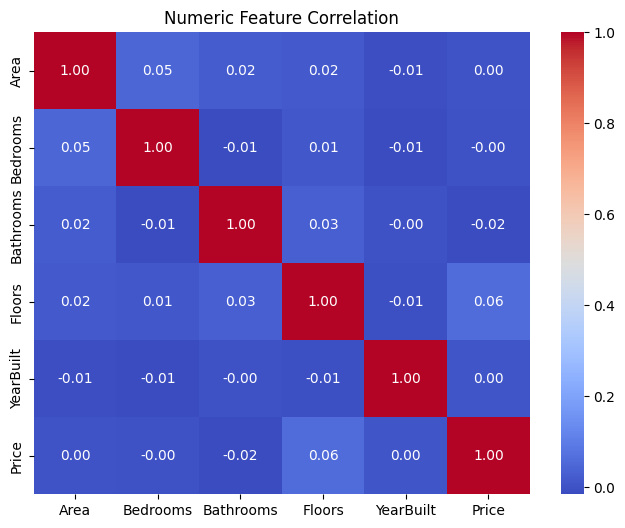

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric correlations
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric Feature Correlation")
plt.show()



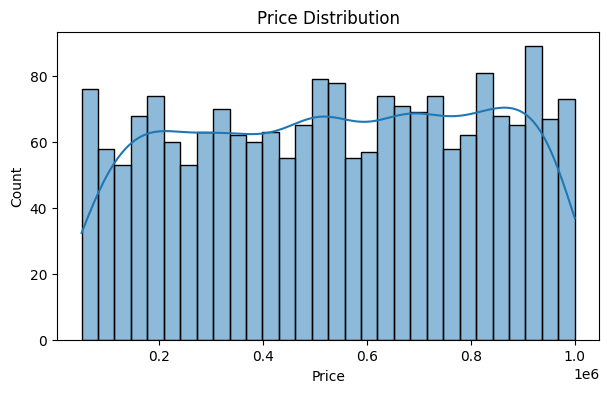

In [ ]:
# Target distribution
plt.figure(figsize=(7, 4))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

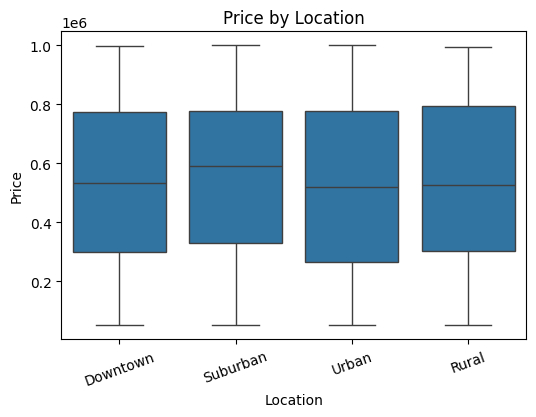

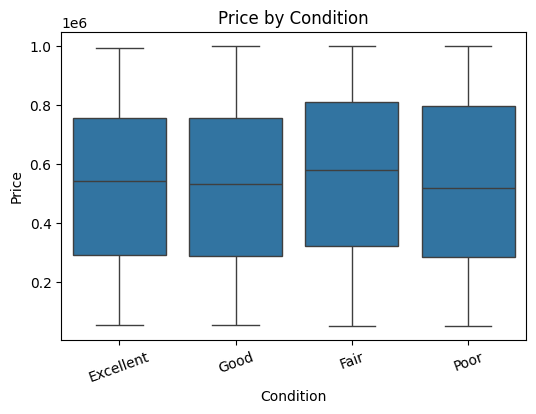

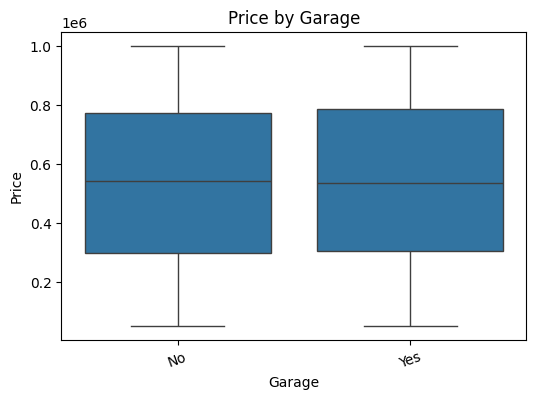

In [ ]:
# Average price by category
for col in ["Location", "Condition", "Garage"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y="Price")
    plt.title(f"Price by {col}")
    plt.xticks(rotation=20)
    plt.show()

# Split and preprocess

Split before fitting any model so your test set stays untouched and honest. For this dataset, use numeric preprocessing for Area, Bedrooms, Bathrooms, Floors, YearBuilt and categorical preprocessing for Location, Condition, and Garage.

In [ ]:
numeric_features = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"]
categorical_features = ["Location", "Condition", "Garage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print(numeric_transformer)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


Testing


In [ ]:
# TEST IT WORKS
print("Before cleaning shape:", X_train.shape)

# Clean the data
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)

print("After cleaning shape:", X_train_clean.shape)
print("First 3 rows of clean data:")
print(X_train_clean[:3])

Before cleaning shape: (1600, 8)
After cleaning shape: (1600, 15)
First 3 rows of clean data:
[[ 1.31408123  0.68575834  1.31608835  1.24226027 -0.80867325  0.
   0.          0.          1.          1.          0.          0.
   0.          1.          0.        ]
 [-1.31595997 -0.01488875  0.41427192 -1.23606446  0.22188292  1.
   0.          0.          0.          0.          0.          1.
   0.          1.          0.        ]
 [-1.03919445 -0.01488875  1.31608835 -1.23606446  0.86249892  0.
   0.          0.          1.          0.          0.          1.
   0.          0.          1.        ]]


In [ ]:
# Simple Linear Regression model
model1 = LinearRegression()

# Train it
model1.fit(X_train_clean, y_train)

# Predict on test data
y_pred1 = model1.predict(X_test_clean)

# Check scores
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
r21 = r2_score(y_test, y_pred1)

print("Linear Regression Results:")
print(f"MSE: {mse1:.0f}")
print(f"RMSE: ${rmse1:.0f}")
print(f"R2: {r21:.3f}")

Linear Regression Results:
MSE: 78321466146
RMSE: $279860
R2: -0.007


In [ ]:
# Random Forest model (usually better)
model2 = RandomForestRegressor(random_state=42)

# Train it
model2.fit(X_train_clean, y_train)

# Predict
y_pred2 = model2.predict(X_test_clean)

# Scores
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r22 = r2_score(y_test, y_pred2)

print("\nRandom Forest Results:")
print(f"MSE: {mse2:.0f}")
print(f"RMSE: ${rmse2:.0f}")
print(f"R2: {r22:.3f}")


Random Forest Results:
MSE: 86571527999
RMSE: $294230
R2: -0.113


In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeRegressor
model3 = DecisionTreeRegressor(random_state=42)

# Train it
model3.fit(X_train_clean, y_train)

# Predict
y_pred3 = model3.predict(X_test_clean)

# Scores
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y_test, y_pred3)

print("\nDecision Tree Results:")
print(f"MSE: {mse3:.0f}")
print(f"RMSE: ${rmse3:.0f}")
print(f"R2: {r23:.3f}")


Decision Tree Results:
MSE: 164126331063
RMSE: $405125
R2: -1.110


In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    full_model = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        full_model,
        X,
        y,
        cv=5,
        scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"),
        return_train_score=True
    )

    train_rmse = -scores["train_neg_root_mean_squared_error"].mean()
    test_rmse = -scores["test_neg_root_mean_squared_error"].mean()
    train_mae = -scores["train_neg_mean_absolute_error"].mean()
    test_mae = -scores["test_neg_mean_absolute_error"].mean()
    train_r2 = scores["train_r2"].mean()
    test_r2 = scores["test_r2"].mean()

    print(f"\n{name}")
    print(f"Train RMSE: {train_rmse:.0f}")
    print(f"Test RMSE: {test_rmse:.0f}")
    print(f"Train MAE: {train_mae:.0f}")
    print(f"Test MAE: {test_mae:.0f}")
    print(f"Train R2: {train_r2:.3f}")
    print(f"Test R2: {test_r2:.3f}")


Linear Regression
Train RMSE: 274987
Test RMSE: 277071
Train MAE: 237573
Test MAE: 239283
Train R2: 0.010
Test R2: -0.008

Decision Tree
Train RMSE: -0
Test RMSE: 393014
Train MAE: -0
Test MAE: 321656
Train R2: 1.000
Test R2: -1.032

Random Forest
Train RMSE: 107609
Test RMSE: 285625
Train MAE: 91164
Test MAE: 245641
Train R2: 0.848
Test R2: -0.072


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

ridge = Ridge()
ridge_params = {"alpha": [0.1, 1.0, 10.0, 100.0]}

search = GridSearchCV(
    ridge, ridge_params,
    cv=5, scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Use your clean data
search.fit(X_train_clean, y_train)

print("Ridge Regression Hyperparameter Tuning Results:")
print("Best alpha:", search.best_params_)
print("Best Cross-Validation RMSE:", -search.best_score_)

# Final best estimator
best_ridge = search.best_estimator_

# Predictions on test data
y_pred_ridge = best_ridge.predict(X_test_clean)

# Predictions on training data for train metrics
y_train_pred_ridge = best_ridge.predict(X_train_clean)

# Calculate Test Metrics
rmse_ridge_test = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge_test = r2_score(y_test, y_pred_ridge)

# Calculate Train Metrics
rmse_ridge_train = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
mae_ridge_train = mean_absolute_error(y_train, y_train_pred_ridge)
r2_ridge_train = r2_score(y_train, y_train_pred_ridge)

print("\nRidge Regression (Tuned) - Performance Metrics:")
print("  --- Test Set ---")
print(f"  RMSE (Test): ${rmse_ridge_test:.0f}")
print(f"  MAE (Test): ${mae_ridge_test:.0f}")
print(f"  R2 (Test): {r2_ridge_test:.3f}")
print("\n  --- Train Set ---")
print(f"  RMSE (Train): ${rmse_ridge_train:.0f}")
print(f"  MAE (Train): ${mae_ridge_train:.0f}")
print(f"  R2 (Train): {r2_ridge_train:.3f}")

print("\nImprovement of Tuned Ridge (Test RMSE) over Linear Regression (Test RMSE):")
print(f"  Delta RMSE: {rmse1 - rmse_ridge_test:.0f}")

Ridge Regression Hyperparameter Tuning Results:
Best alpha: {'alpha': 100.0}
Best Cross-Validation RMSE: 276265.4173874343

Ridge Regression (Tuned) - Performance Metrics:
  --- Test Set ---
  RMSE (Test): $279809
  MAE (Test): $243330
  R2 (Test): -0.006

  --- Train Set ---
  RMSE (Train): $274354
  MAE (Train): $237161
  R2 (Train): 0.010

Improvement of Tuned Ridge (Test RMSE) over Linear Regression (Test RMSE):
  Delta RMSE: 51


### Comprehensive Model Comparison: All Metrics

Let's gather all the calculated regression metrics (RMSE, MAE, and R-squared) for both training and test sets across all models for a complete overview.

In [ ]:
# Calculate MAE for Linear Regression (if not already present)
mae1 = mean_absolute_error(y_test, y_pred1)
y_train_pred1 = model1.predict(X_train_clean)
mae1_train = mean_absolute_error(y_train, y_train_pred1)

# Calculate MAE for Random Forest (if not already present)
mae2 = mean_absolute_error(y_test, y_pred2)
y_train_pred2 = model2.predict(X_train_clean)
mae2_train = mean_absolute_error(y_train, y_train_pred2)

# Calculate MAE for Decision Tree (if not already present)
mae3 = mean_absolute_error(y_test, y_pred3)
y_train_pred3 = model3.predict(X_train_clean)
mae3_train = mean_absolute_error(y_train, y_train_pred3)

print("\n--- ALL MODELS PERFORMANCE COMPARISON ---")
print("\nLinear Regression:")
print(f"  --- Train Set ---")
print(f"  RMSE (Train): ${np.sqrt(mean_squared_error(y_train, y_train_pred1)):.0f}")
print(f"  MAE (Train): ${mae1_train:.0f}")
print(f"  R2 (Train): {r21_train:.3f}")
print(f"  --- Test Set ---")
print(f"  RMSE (Test): ${rmse1:.0f}")
print(f"  MAE (Test): ${mae1:.0f}")
print(f"  R2 (Test): {r21:.3f}")

print("\nRandom Forest:")
print(f"  --- Train Set ---")
print(f"  RMSE (Train): ${np.sqrt(mean_squared_error(y_train, y_train_pred2)):.0f}")
print(f"  MAE (Train): ${mae2_train:.0f}")
print(f"  R2 (Train): {r22_train:.3f}")
print(f"  --- Test Set ---")
print(f"  RMSE (Test): ${rmse2:.0f}")
print(f"  MAE (Test): ${mae2:.0f}")
print(f"  R2 (Test): {r22:.3f}")

print("\nDecision Tree:")
print(f"  --- Train Set ---")
print(f"  RMSE (Train): ${np.sqrt(mean_squared_error(y_train, y_train_pred3)):.0f}")
print(f"  MAE (Train): ${mae3_train:.0f}")
print(f"  R2 (Train): {r23_train:.3f}")
print(f"  --- Test Set ---")
print(f"  RMSE (Test): ${rmse3:.0f}")
print(f"  MAE (Test): ${mae3:.0f}")
print(f"  R2 (Test): {r23:.3f}")

print("\nRidge Regression (Tuned):")
print(f"  --- Train Set ---")
print(f"  RMSE (Train): ${rmse_ridge_train:.0f}")
print(f"  MAE (Train): ${mae_ridge_train:.0f}")
print(f"  R2 (Train): {r2_ridge_train:.3f}")
print(f"  --- Test Set ---")
print(f"  RMSE (Test): ${rmse_ridge_test:.0f}")
print(f"  MAE (Test): ${mae_ridge_test:.0f}")
print(f"  R2 (Test): {r2_ridge_test:.3f}")

# Re-evaluate best model based on Test RMSE
models_rmse = {
    "Linear": rmse1,
    "Decision Tree": rmse3,
    "Random Forest": rmse2,
    "Ridge (Tuned)": rmse_ridge_test
}

best_model_name_rmse = min(models_rmse, key=models_rmse.get)
print(f"\n🏆 BEST MODEL (lowest Test RMSE): {best_model_name_rmse}")



--- ALL MODELS PERFORMANCE COMPARISON ---

Linear Regression:
  --- Train Set ---
  RMSE (Train): $274333
  MAE (Train): $237122
  R2 (Train): 0.010
  --- Test Set ---
  RMSE (Test): $279860
  MAE (Test): $243242
  R2 (Test): -0.007

Random Forest:
  --- Train Set ---
  RMSE (Train): $107608
  MAE (Train): $91108
  R2 (Train): 0.848
  --- Test Set ---
  RMSE (Test): $294230
  MAE (Test): $254588
  R2 (Test): -0.113

Decision Tree:
  --- Train Set ---
  RMSE (Train): $0
  MAE (Train): $0
  R2 (Train): 1.000
  --- Test Set ---
  RMSE (Test): $405125
  MAE (Test): $332170
  R2 (Test): -1.110

Ridge Regression (Tuned):
  --- Train Set ---
  RMSE (Train): $274354
  MAE (Train): $237161
  R2 (Train): 0.010
  --- Test Set ---
  RMSE (Test): $279809
  MAE (Test): $243330
  R2 (Test): -0.006

🏆 BEST MODEL (lowest Test RMSE): Ridge (Tuned)
